<a href="https://colab.research.google.com/github/bosiqbal/segmentasi-citra/blob/main/segmentasikupu_kupu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving OIP (4).jpeg to OIP (4).jpeg


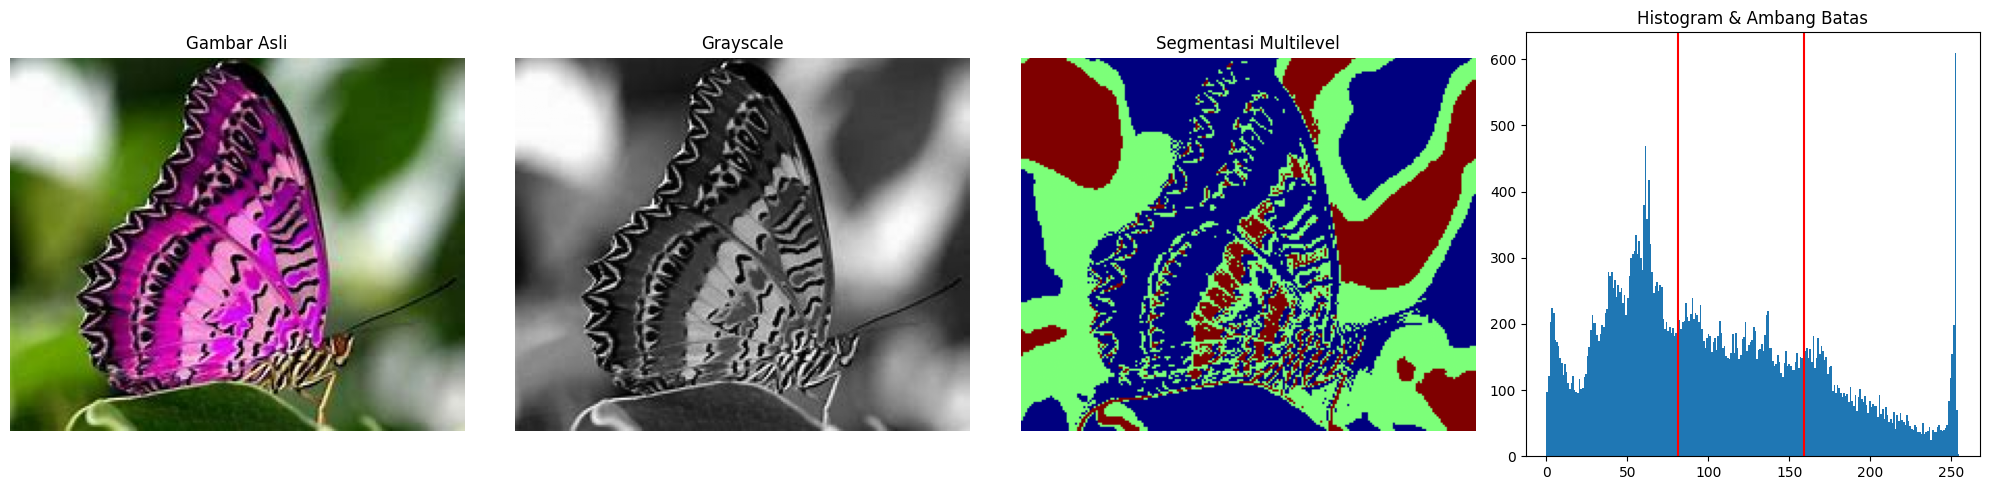

Nilai Thresholds: [ 81 159]


In [ ]:
# === 1. Install dan Import Library ===
!pip install opencv-python-headless matplotlib scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.filters import threshold_multiotsu

# === 2. Upload Gambar Citra Kupu-Kupu ===
from google.colab import files
uploaded = files.upload()

# === 3. Baca Gambar dan Konversi ke Grayscale ===
for filename in uploaded.keys():
    image = io.imread(filename)

gray = color.rgb2gray(image)  # Normalisasi otomatis 0–1
gray_uint8 = (gray * 255).astype(np.uint8)  # Skala 0–255

# === 4. Terapkan Multilevel Thresholding (3 kelas) ===
thresholds = threshold_multiotsu(gray_uint8, classes=3)

# Segmentasi berdasarkan nilai ambang
regions = np.digitize(gray_uint8, bins=thresholds)

# === 5. Tampilkan Hasil ===
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(image)
ax[0].set_title("Gambar Asli")
ax[0].axis("off")

ax[1].imshow(gray_uint8, cmap='gray')
ax[1].set_title("Grayscale")
ax[1].axis("off")

ax[2].imshow(regions, cmap='jet')
ax[2].set_title("Segmentasi Multilevel")
ax[2].axis("off")

# Tampilkan nilai ambang
ax[3].hist(gray_uint8.ravel(), bins=256)
for t in thresholds:
    ax[3].axvline(t, color='r')
ax[3].set_title("Histogram & Ambang Batas")

plt.tight_layout()
plt.show()

# Cetak ambang batas
print("Nilai Thresholds:", thresholds)
